In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='husl')
plt.rcParams['figure.dpi'] = 120

print(f"Pandas  : {pd.__version__}")
print(f"Numpy   : {np.__version__}")
print("✅ Ready")

Pandas  : 3.0.3
Numpy   : 2.5.0
✅ Ready


In [8]:
users        = pd.read_csv('../data/raw/users.csv')
courses      = pd.read_csv('../data/raw/courses.csv')
transactions = pd.read_csv('../data/raw/transactions.csv')

# Fix date type immediately
transactions['EnrollmentDate'] = pd.to_datetime(transactions['EnrollmentDate'])

print("Data loaded:")
print(f"  Users        : {users.shape}")
print(f"  Courses      : {courses.shape}")
print(f"  Transactions : {transactions.shape}")

Data loaded:
  Users        : (2000, 6)
  Courses      : (396, 9)
  Transactions : (23942, 7)


In [9]:
# Join transactions with course info and user info
master = (transactions
          .merge(courses, on='CourseID', how='left')
          .merge(users,   on='UserID',   how='left'))

print(f"Master table shape : {master.shape}")
print(f"Columns            : {master.columns.tolist()}")
print()
master.head(3)

Master table shape : (23942, 20)
Columns            : ['UserID', 'CourseID', 'EnrollmentDate', 'Amount', 'CompletionStatus', 'CPDPointsEarned', 'CertificateIssued', 'CourseTitle', 'CourseCategory', 'CourseType', 'CourseLevel', 'CourseRating', 'PriceZAR', 'CPDPoints', 'AccreditationBody', 'Age', 'Gender', 'ProfessionType', 'YearsExperience', 'Country']



,UserID,CourseID,EnrollmentDate,Amount,CompletionStatus,CPDPointsEarned,CertificateIssued,CourseTitle,CourseCategory,CourseType,CourseLevel,CourseRating,PriceZAR,CPDPoints,AccreditationBody,Age,Gender,ProfessionType,YearsExperience,Country
0,P0001,C0162,2022-02-21,1031.54,Completed,4,True,PE Modifications for Special Needs (Intermediate),Classroom Interventions,Mini Course,Intermediate,4.8,953.73,4,NaN,25,Female,Classroom Teacher,11,South Africa
1,P0001,C0117,2022-09-25,536.23,Completed,4,True,Stability: The Core in FMS (Intermediate),Fundamental Movement Skills,Live Workshop,Intermediate,3.5,499.94,4,HPCSA,25,Female,Classroom Teacher,11,South Africa
2,P0001,C0270,2023-06-03,824.87,Completed,4,True,How to Present Movement Classes Like a Pro (In...,Sport & Leisure,Webinar,Intermediate,3.6,752.50,4,SASHP,25,Female,Classroom Teacher,11,South Africa


In [10]:
# One row per user — summary statistics
profiles = master.groupby('UserID').agg(

    # Enrollment behaviour
    total_courses      = ('CourseID',        'nunique'),  # unique courses only
    total_transactions = ('CourseID',        'count'),    # total purchases
    total_spending     = ('Amount',          'sum'),
    avg_spending       = ('Amount',          'mean'),
    min_spending       = ('Amount',          'min'),
    max_spending       = ('Amount',          'max'),

    # Course quality
    avg_course_rating  = ('CourseRating',    'mean'),

    # Category diversity
    n_categories       = ('CourseCategory',  'nunique'),

    # Time features
    first_enroll       = ('EnrollmentDate', 'min'),
    last_enroll        = ('EnrollmentDate', 'max'),

).reset_index()

print(f"Profiles shape : {profiles.shape}")
print(f"Columns        : {profiles.columns.tolist()}")
profiles.head(3)

Profiles shape : (2000, 11)
Columns        : ['UserID', 'total_courses', 'total_transactions', 'total_spending', 'avg_spending', 'min_spending', 'max_spending', 'avg_course_rating', 'n_categories', 'first_enroll', 'last_enroll']


,UserID,total_courses,total_transactions,total_spending,avg_spending,min_spending,max_spending,avg_course_rating,n_categories,first_enroll,last_enroll
0,P0001,18,18,13705.26,761.403333,348.67,1227.80,4.266667,6,2022-02-21,2025-09-24
1,P0002,16,16,10798.06,674.878750,336.05,1151.31,4.475000,6,2022-01-05,2025-12-30
2,P0003,15,15,11014.89,734.326000,378.28,1417.63,4.446667,6,2022-04-10,2025-10-13


In [11]:
# Find which category each user enrolled in most
pref_cat = (master
            .groupby(['UserID', 'CourseCategory'])
            .size()
            .reset_index(name='count')
            .sort_values('count', ascending=False)
            .drop_duplicates(subset='UserID')
            [['UserID', 'CourseCategory']]
            .rename(columns={'CourseCategory': 'preferred_category'}))

# Merge into profiles
profiles = profiles.merge(pref_cat, on='UserID', how='left')

print("Preferred category added ✅")
print(profiles['preferred_category'].value_counts())

Preferred category added ✅
preferred_category
DCD & Motor Disorders          643
Fundamental Movement Skills    406
Classroom Interventions        314
Sensory Processing             311
Assessment & Diagnosis         164
Sport & Leisure                162
Name: count, dtype: int64


In [12]:
# Find which level each user enrolled in most
pref_lvl = (master
            .groupby(['UserID', 'CourseLevel'])
            .size()
            .reset_index(name='count')
            .sort_values('count', ascending=False)
            .drop_duplicates(subset='UserID')
            [['UserID', 'CourseLevel']]
            .rename(columns={'CourseLevel': 'preferred_level'}))

# Merge into profiles
profiles = profiles.merge(pref_lvl, on='UserID', how='left')

print("Preferred level added ✅")
print(profiles['preferred_level'].value_counts())

Preferred level added ✅
preferred_level
Beginner        798
Intermediate    737
Advanced        465
Name: count, dtype: int64


In [13]:
# Count how many courses each user took at each level
level_counts = (master
                .groupby(['UserID', 'CourseLevel'])
                .size()
                .unstack(fill_value=0)
                .reset_index())

# Make sure all 3 columns exist even if someone has 0 in one
for lvl in ['Beginner', 'Intermediate', 'Advanced']:
    if lvl not in level_counts.columns:
        level_counts[lvl] = 0

# Merge into profiles
profiles = profiles.merge(
    level_counts[['UserID', 'Beginner', 'Intermediate', 'Advanced']],
    on='UserID', how='left'
)

print("Level counts added ✅")
profiles[['UserID','Beginner','Intermediate','Advanced']].head(5)

Level counts added ✅


,UserID,Beginner,Intermediate,Advanced
0,P0001,5,11,2
1,P0002,6,8,2
2,P0003,8,4,3
3,P0004,0,1,0
4,P0005,0,2,9


In [14]:
# Bring in Age and Gender from users table
profiles = profiles.merge(
    users[['UserID', 'Age', 'Gender']],
    on='UserID', how='left'
)

print("Demographics added ✅")
profiles[['UserID','Age','Gender']].head(5)

Demographics added ✅


,UserID,Age,Gender
0,P0001,25,Female
1,P0002,52,Female
2,P0003,48,Female
3,P0004,39,Female
4,P0005,39,Female


In [15]:
# ── Time Features ──────────────────────────────
duration_days = (
    (profiles['last_enroll'] - profiles['first_enroll']).dt.days + 1
)


# How frequently does the user enroll (courses per active day)
profiles['enrollment_frequency'] = (
    profiles['total_courses'] / duration_days
)

# Days since last enrollment (recency)
reference_date = pd.Timestamp('2026-01-01')
profiles['recency_days'] = (
    reference_date - profiles['last_enroll']
).dt.days


# ── Diversity Features ─────────────────────────
# How many different categories explored (raw count)
profiles['diversity_score'] = profiles['n_categories']

# Category concentration (1 = only 1 category, 0 = all categories)
profiles['category_concentration'] = (
    1 - (profiles['n_categories'] / 8)
)


# ── Learning Depth Features ────────────────────
total_lvl = (
    profiles['Beginner'] +
    profiles['Intermediate'] +
    profiles['Advanced']
).replace(0, 1)  # avoid divide by zero

# Depth index: 0 = all beginner, 1 = all advanced
profiles['learning_depth_index'] = (
    (profiles['Intermediate'] + 2 * profiles['Advanced']) /
    (2 * total_lvl)
)

# What % of their courses are beginner level
profiles['beginner_ratio'] = profiles['Beginner'] / total_lvl

# What % of their courses are advanced level
profiles['advanced_ratio'] = profiles['Advanced'] / total_lvl


print("✅ All derived features calculated")
print()
print("New features added:")
new_feats = [
    'enrollment_frequency', 'recency_days',
    'diversity_score', 'category_concentration',
    'learning_depth_index', 'beginner_ratio', 'advanced_ratio'
]
for f in new_feats:
    print(f"  {f:<30} | mean={profiles[f].mean():.3f} | min={profiles[f].min():.3f} | max={profiles[f].max():.3f}")

✅ All derived features calculated

New features added:
  enrollment_frequency           | mean=0.050 | min=0.002 | max=1.000
  recency_days                   | mean=187.188 | min=2.000 | max=1460.000
  diversity_score                | mean=4.444 | min=1.000 | max=6.000
  category_concentration         | mean=0.444 | min=0.250 | max=0.875
  learning_depth_index           | mean=0.446 | min=0.000 | max=1.000
  beginner_ratio                 | mean=0.366 | min=0.000 | max=1.000
  advanced_ratio                 | mean=0.259 | min=0.000 | max=1.000


In [16]:
from sklearn.preprocessing import LabelEncoder

# Derive actual categories from the data
CATEGORIES = sorted(master['CourseCategory'].dropna().unique().tolist())
LEVELS = ['Beginner', 'Intermediate', 'Advanced']

le_cat = LabelEncoder()
le_lvl = LabelEncoder()

le_cat.fit(CATEGORIES)
le_lvl.fit(LEVELS)

# Fill any NaN with the first category alphabetically
profiles['preferred_category_enc'] = le_cat.transform(
    profiles['preferred_category'].fillna(CATEGORIES[0])
)
profiles['preferred_level_enc'] = le_lvl.transform(
    profiles['preferred_level'].fillna('Beginner')
)

print("Encoding mapping — Category:")
for i, cat in enumerate(le_cat.classes_):
    print(f"  {cat:<25} → {i}")

print("\nEncoding mapping — Level:")
for i, lvl in enumerate(le_lvl.classes_):
    print(f"  {lvl:<15} → {i}")

Encoding mapping — Category:
  Assessment & Diagnosis    → 0
  Classroom Interventions   → 1
  DCD & Motor Disorders     → 2
  Fundamental Movement Skills → 3
  Sensory Processing        → 4
  Sport & Leisure           → 5

Encoding mapping — Level:
  Advanced        → 0
  Beginner        → 1
  Intermediate    → 2


In [17]:
# Fill any remaining nulls with 0
profiles = profiles.fillna(0)

# Replace infinity values
profiles = profiles.replace([np.inf, -np.inf], 0)

# Verify no nulls remain
null_check = profiles.isnull().sum()
print("Null check after cleaning:")
print(null_check[null_check > 0] if null_check.sum() > 0 else "  No nulls ✅")

Null check after cleaning:
  No nulls ✅


In [18]:
CLUSTERING_FEATURES = [
    'total_courses',
    'avg_spending',
    'avg_course_rating',
    'diversity_score',
    'learning_depth_index',
    'beginner_ratio',
    'enrollment_frequency',
    'category_concentration',
    'n_categories',
    'recency_days',
    'preferred_category_enc',
    'preferred_level_enc'
]

print("═══════════════════════════════════════════")
print("   FINAL FEATURE MATRIX SUMMARY")
print("═══════════════════════════════════════════")
print(f"Total users    : {len(profiles)}")
print(f"Total features : {len(CLUSTERING_FEATURES)}")
print()
print(f"{'Feature':<30} {'Mean':>8} {'Min':>8} {'Max':>8}")
print("─" * 58)
for f in CLUSTERING_FEATURES:
    print(f"{f:<30} {profiles[f].mean():>8.3f} {profiles[f].min():>8.3f} {profiles[f].max():>8.3f}")

═══════════════════════════════════════════
   FINAL FEATURE MATRIX SUMMARY
═══════════════════════════════════════════
Total users    : 2000
Total features : 12

Feature                            Mean      Min      Max
──────────────────────────────────────────────────────────
total_courses                    11.971    1.000   36.000
avg_spending                    750.632  288.720 1546.810
avg_course_rating                 4.329    3.300    5.000
diversity_score                   4.444    1.000    6.000
learning_depth_index              0.446    0.000    1.000
beginner_ratio                    0.366    0.000    1.000
enrollment_frequency              0.050    0.002    1.000
category_concentration            0.444    0.250    0.875
n_categories                      4.444    1.000    6.000
recency_days                    187.188    2.000 1460.000
preferred_category_enc            2.436    0.000    5.000
preferred_level_enc               1.136    0.000    2.000


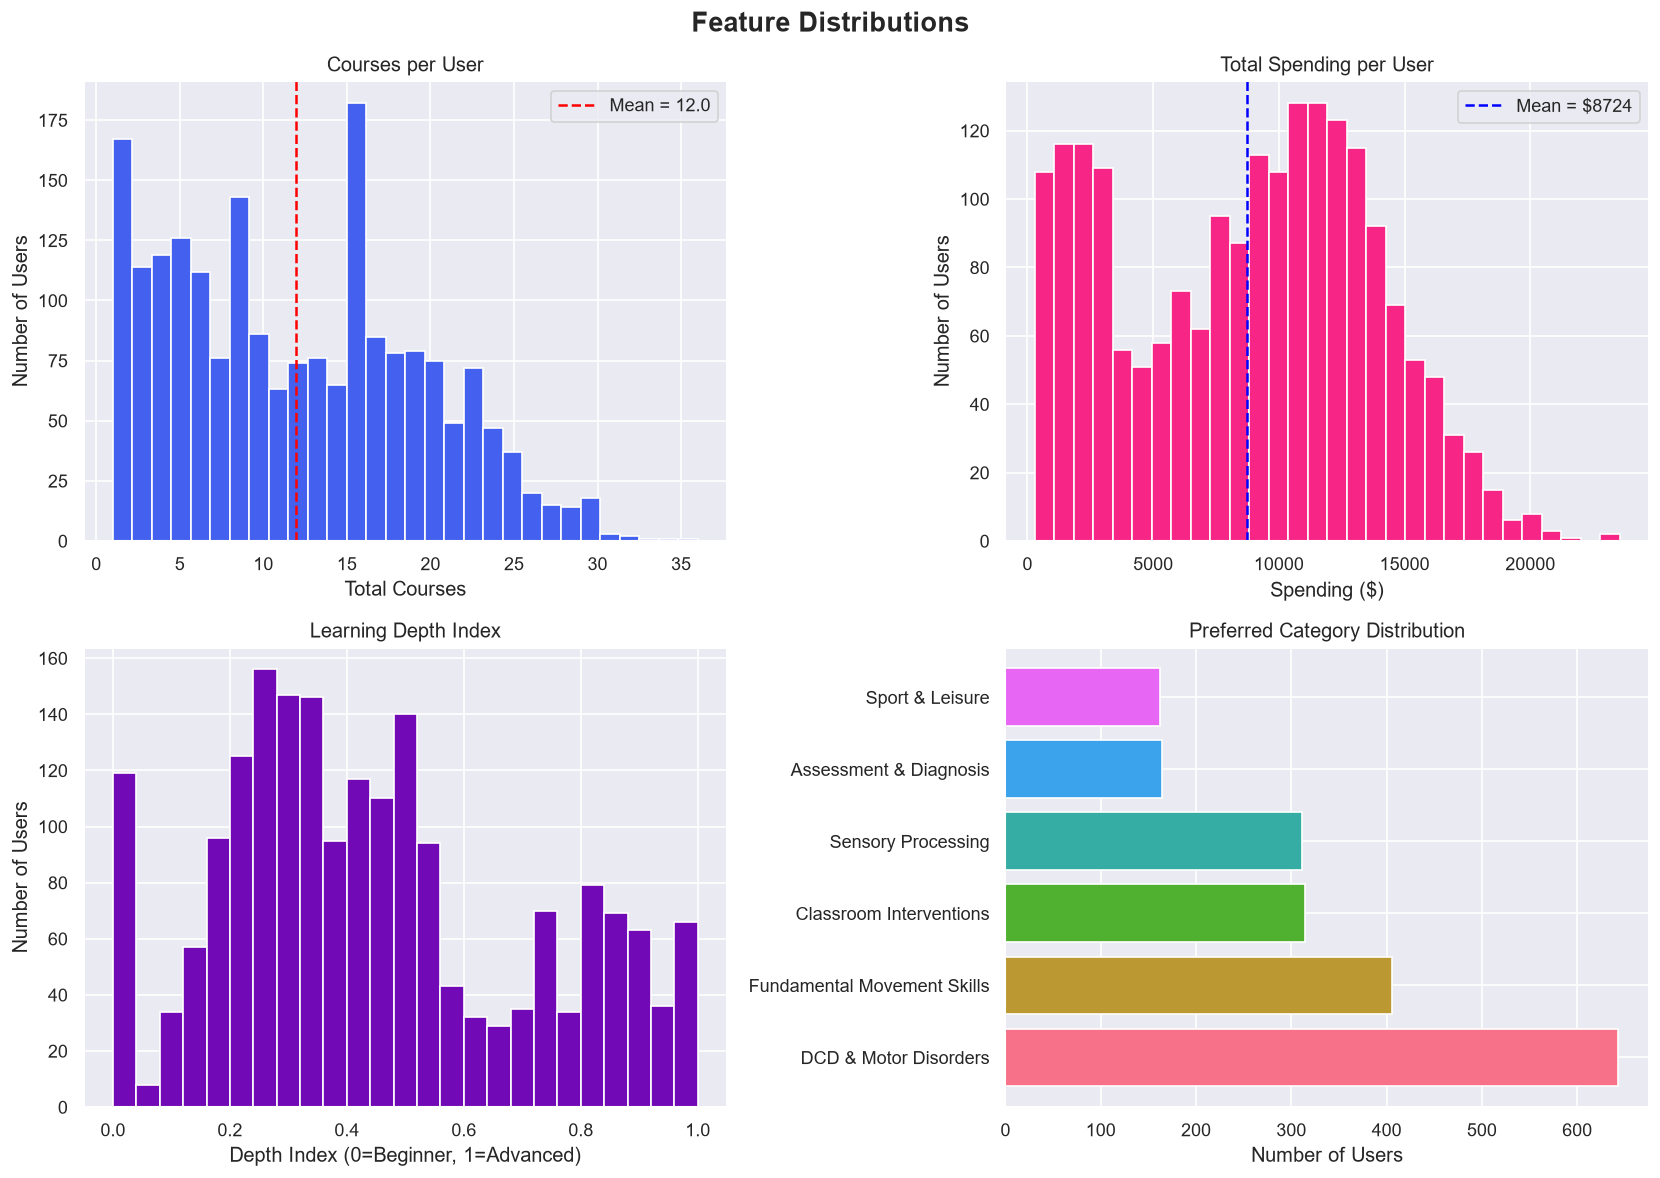

Saved ✅


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Distributions', fontsize=16, fontweight='bold')

# Chart 1 — Total courses per user
axes[0,0].hist(profiles['total_courses'], bins=30,
               color='#4361ee', edgecolor='white')
axes[0,0].set_title('Courses per User')
axes[0,0].set_xlabel('Total Courses')
axes[0,0].set_ylabel('Number of Users')
axes[0,0].axvline(profiles['total_courses'].mean(),
                  color='red', linestyle='--',
                  label=f"Mean = {profiles['total_courses'].mean():.1f}")
axes[0,0].legend()

# Chart 2 — Total spending per user
axes[0,1].hist(profiles['total_spending'], bins=30,
               color='#f72585', edgecolor='white')
axes[0,1].set_title('Total Spending per User')
axes[0,1].set_xlabel('Spending ($)')
axes[0,1].set_ylabel('Number of Users')
axes[0,1].axvline(profiles['total_spending'].mean(),
                  color='blue', linestyle='--',
                  label=f"Mean = ${profiles['total_spending'].mean():.0f}")
axes[0,1].legend()

# Chart 3 — Learning depth index
axes[1,0].hist(profiles['learning_depth_index'], bins=25,
               color='#7209b7', edgecolor='white')
axes[1,0].set_title('Learning Depth Index')
axes[1,0].set_xlabel('Depth Index (0=Beginner, 1=Advanced)')
axes[1,0].set_ylabel('Number of Users')

# Chart 4 — Preferred category
cat_counts = profiles['preferred_category'].value_counts()
axes[1,1].barh(cat_counts.index, cat_counts.values,
               color=sns.color_palette('husl', len(cat_counts)))
axes[1,1].set_title('Preferred Category Distribution')
axes[1,1].set_xlabel('Number of Users')

plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/07_feature_distributions.png', dpi=150)
plt.show()
print("Saved ✅")

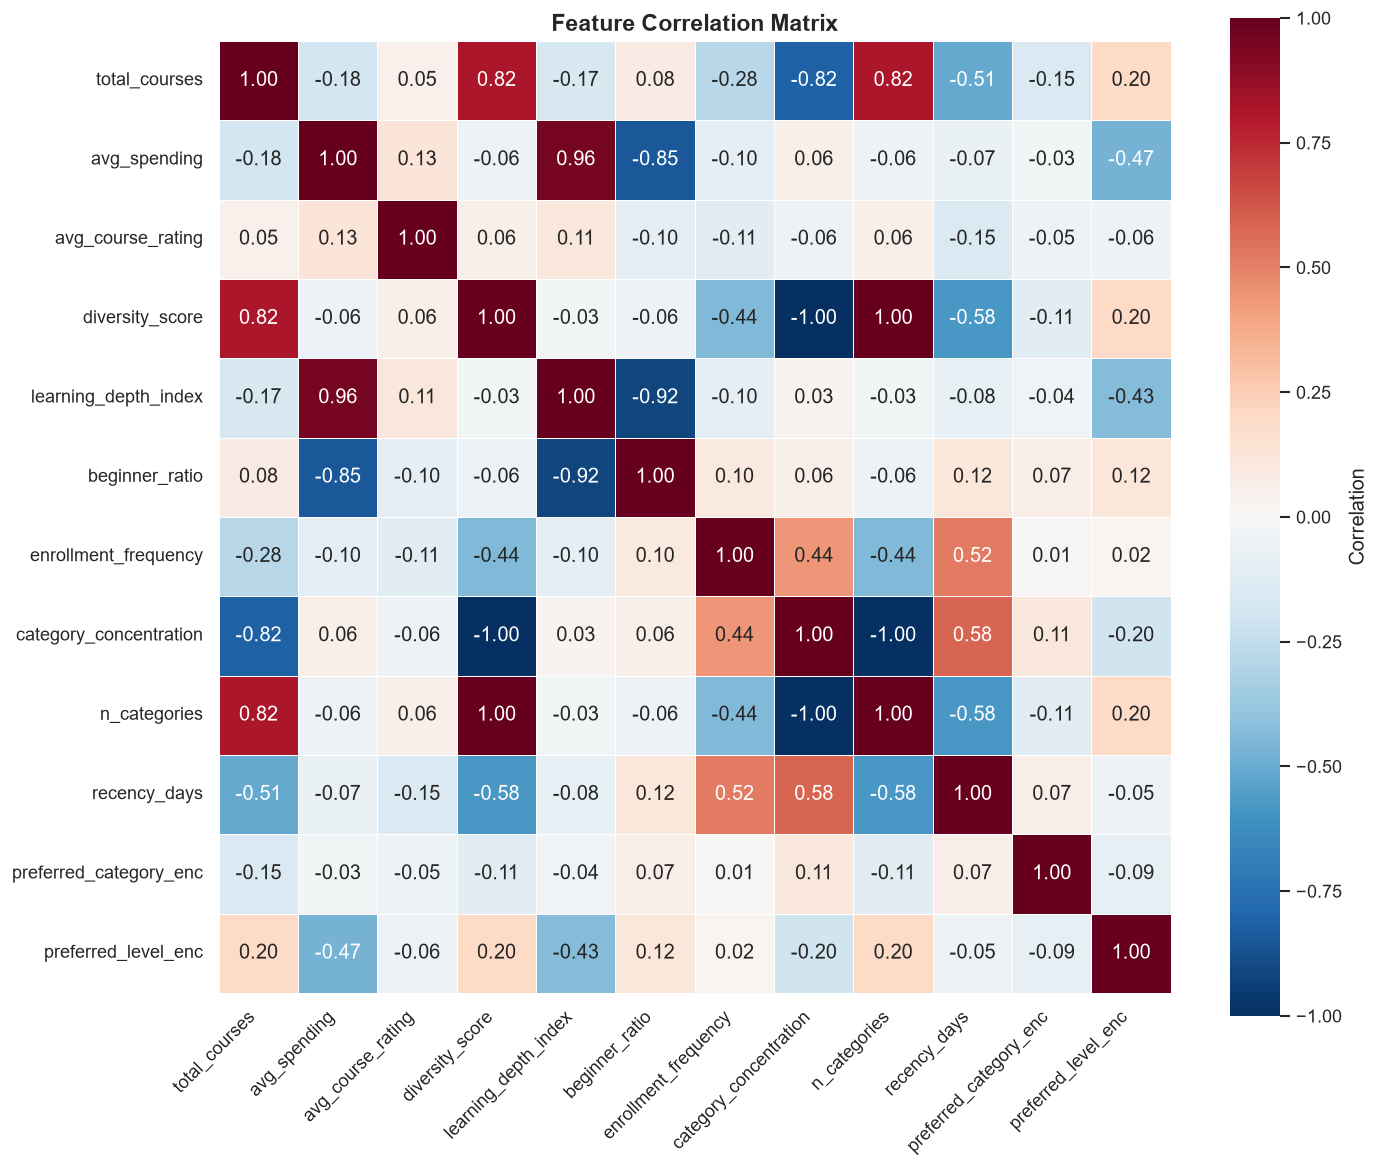

Saved ✅


In [20]:
fig, ax = plt.subplots(figsize=(12, 10))

corr = profiles[CLUSTERING_FEATURES].corr().round(2)

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Correlation'}
)

ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/08_correlation_matrix.png', dpi=150)
plt.show()
print("Saved ✅")

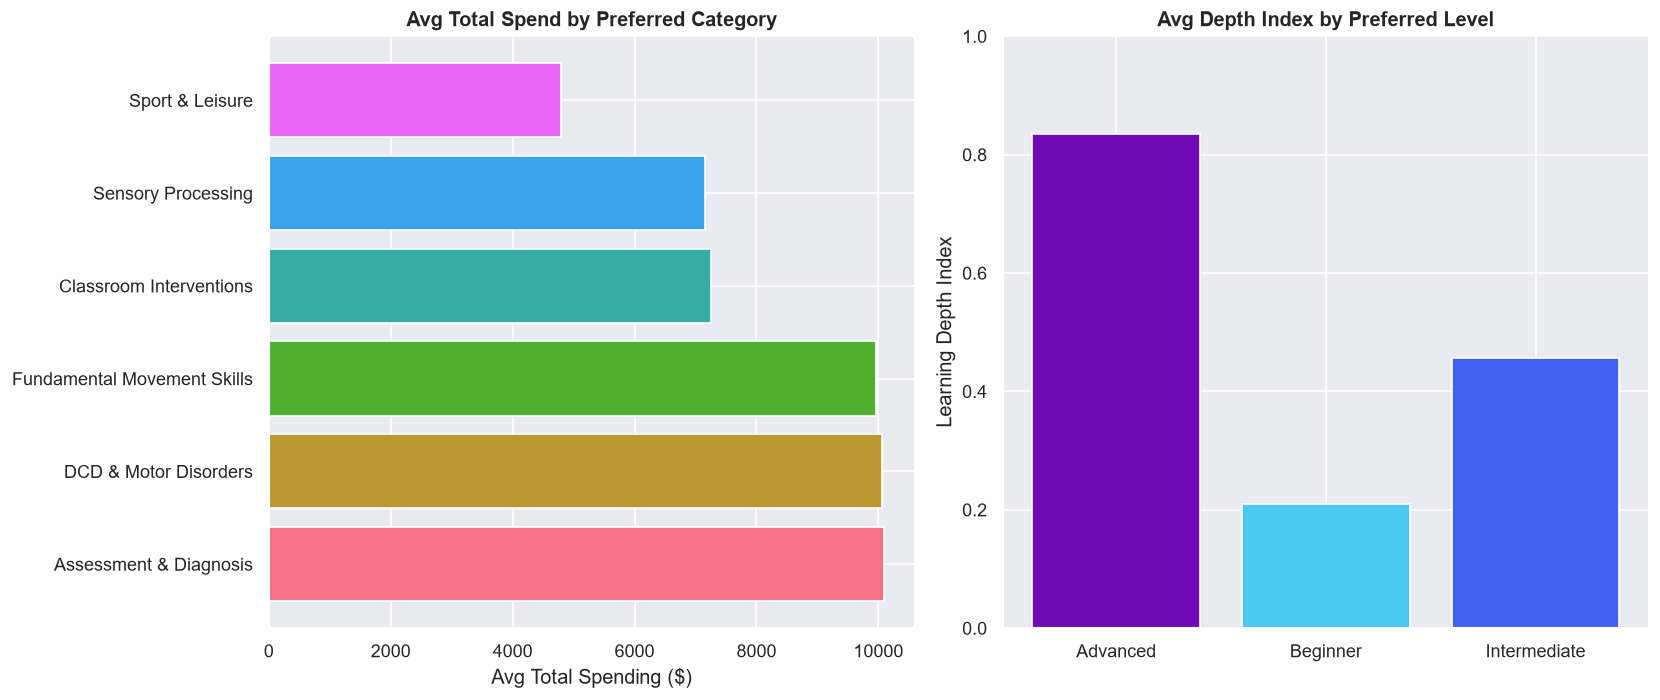

Saved ✅


In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Avg spending by preferred category
cat_spend = (profiles.groupby('preferred_category')['total_spending']
                     .mean()
                     .sort_values(ascending=False)
                     .reset_index())

ax1.barh(cat_spend['preferred_category'],
         cat_spend['total_spending'],
         color=sns.color_palette('husl', len(cat_spend)))
ax1.set_title('Avg Total Spend by Preferred Category', fontweight='bold')
ax1.set_xlabel('Avg Total Spending ($)')

# Avg depth index by preferred level
lvl_depth = (profiles.groupby('preferred_level')['learning_depth_index']
                     .mean()
                     .reset_index())

colors = {'Beginner':'#4cc9f0', 'Intermediate':'#4361ee', 'Advanced':'#7209b7'}
bar_colors = [colors[l] for l in lvl_depth['preferred_level']]
ax2.bar(lvl_depth['preferred_level'],
        lvl_depth['learning_depth_index'],
        color=bar_colors, edgecolor='white')
ax2.set_title('Avg Depth Index by Preferred Level', fontweight='bold')
ax2.set_ylabel('Learning Depth Index')
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../reports/figures/09_category_level_analysis.png', dpi=150)
plt.show()
print("Saved ✅")

In [ ]:
# Make sure output folder exists
os.makedirs('../data/processed', exist_ok=True)

# Save full profiles
profiles.to_csv('../data/processed/master_profiles.csv', index=False)

# Save just the feature matrix (for clustering)
feature_matrix = profiles[['UserID'] + CLUSTERING_FEATURES]
feature_matrix.to_csv('../data/processed/feature_matrix.csv', index=False)

print(f"  master_profiles.csv  → {len(profiles)} rows × {len(profiles.columns)} columns")
print(f"  feature_matrix.csv   → {len(feature_matrix)} rows × {len(feature_matrix.columns)} columns")
print()
print("Saved to data/processed/ ✅")
print()


═══════════════════════════════════════════
   DAY 2 COMPLETE — FILES SAVED
═══════════════════════════════════════════
  master_profiles.csv  → 2000 rows × 27 columns
  feature_matrix.csv   → 2000 rows × 13 columns

Saved to data/processed/ ✅

